# Regime Change Detection in Financial Time Series

## 1. Definition

For detecting regime changes, we utilize the **Markov Switching Dynamic Regression (MSDR)** model. The model assumes that the parameters of the time series depend on an unobserved state variable $S_t \in \{1, ..., K\}$.

The general equation for a process with $K$ regimes is:

$$y_t = \mu_{S_t} + \epsilon_t, \quad \epsilon_t \sim N(0, \sigma^2_{S_t})$$

Where:
- $y_t$ is the log return of the asset at time $t$.
- $\mu_{S_t}$ is the mean return in regime $S_t$.
- $\sigma^2_{S_t}$ is the variance in regime $S_t$.
- The transition between states is governed by a transition matrix $P$:
  $$P = \begin{pmatrix} p_{11} & p_{12} \\ p_{21} & p_{22} \end{pmatrix}$$
  where $p_{ij} = P(S_t = j | S_{t-1} = i)$.

## 2. Description
The Markov Switching Model identifies hidden states (regimes) in data, such as a shift from a low-volatility 'bull' market to a high-volatility 'bear' market, by allowing parameters to vary over time. It is particularly effective for financial series that exhibit non-stationarity and sudden structural breaks.

## 3. Data Selection and Reasoning

**Selected Dataset:** NASDAQ-100 ETF (QQQ)

**Reasoning:** The NASDAQ index was chosen because the period 2020-2025 covers several distinct economic regimes: the COVID-19 crash, the subsequent tech-driven recovery, the inflationary period of 2022, and the AI-driven growth of 2023-2024. These clear shifts in volatility and mean returns make it an ideal candidate for testing regime-switching models.

In [4]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression

# Load financial data for QQQ
qqq_ticker = yf.Ticker("QQQ")
hist = qqq_ticker.history(start="2020-01-01", end="2025-01-01")
financial_data = {'QQQ': hist}

# 1. Prepare Data (Calculate Log Returns)
qqq_data = financial_data['QQQ']['Close'].copy()
qqq_returns = 100 * np.log(qqq_data / qqq_data.shift(1)).dropna()

# 2. Fit the Model (2 states: Low Volatility vs High Volatility)
# We model the variance (switching_variance=True)
model = MarkovRegression(qqq_returns, k_regimes=2, trend='c', switching_variance=True)
model_results = model.fit()

print(model_results.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                        Markov Switching Model Results                        
Dep. Variable:                  Close   No. Observations:                 1257
Model:               MarkovRegression   Log Likelihood               -2222.015
Date:                Fri, 08 May 2026   AIC                           4456.030
Time:                        08:35:29   BIC                           4486.849
Sample:                             0   HQIC                          4467.613
                               - 1257                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1746      0.038      4.603      0.000       0.100       0.249
sigma2         1.0738      0.075     14.260      0.0

## 4. Diagram: Exploratory Plots

Below, we visualize the raw Close prices and the calculated daily log returns to identify visual evidence of regime shifts.

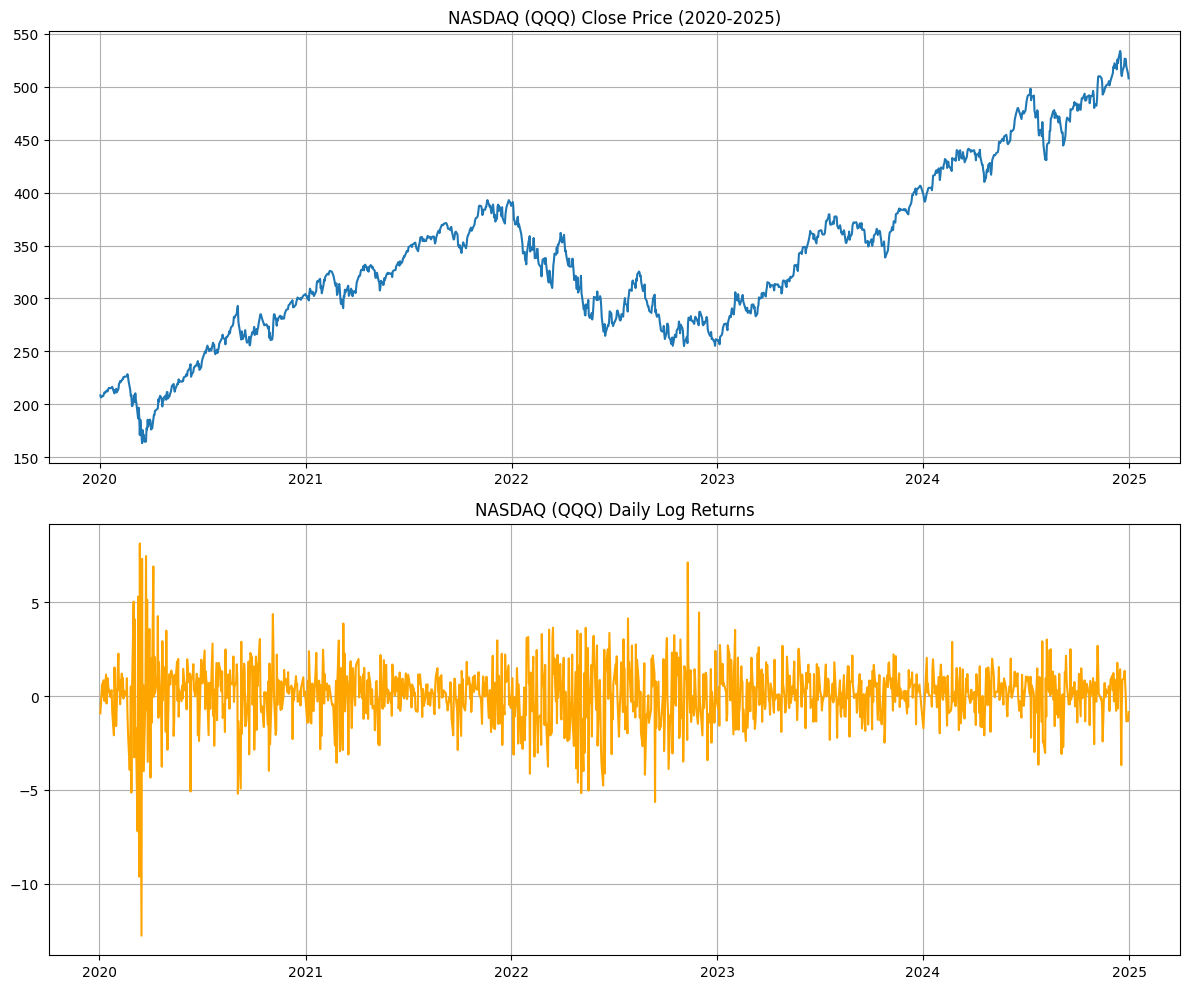

In [5]:
fig, ax = plt.subplots(2, 1, figsize=(12, 10))

ax[0].plot(qqq_data)
ax[0].set_title('NASDAQ (QQQ) Close Price (2020-2025)')
ax[0].grid(True)

ax[1].plot(qqq_returns, color='orange')
ax[1].set_title('NASDAQ (QQQ) Daily Log Returns')
ax[1].grid(True)

plt.tight_layout()
plt.show()

## 5. Diagnosis: Diagnostic Plots

To diagnose the model, we plot the 'Smoothed Probabilities'. This shows the model's certainty about which regime the market was in at any given date.

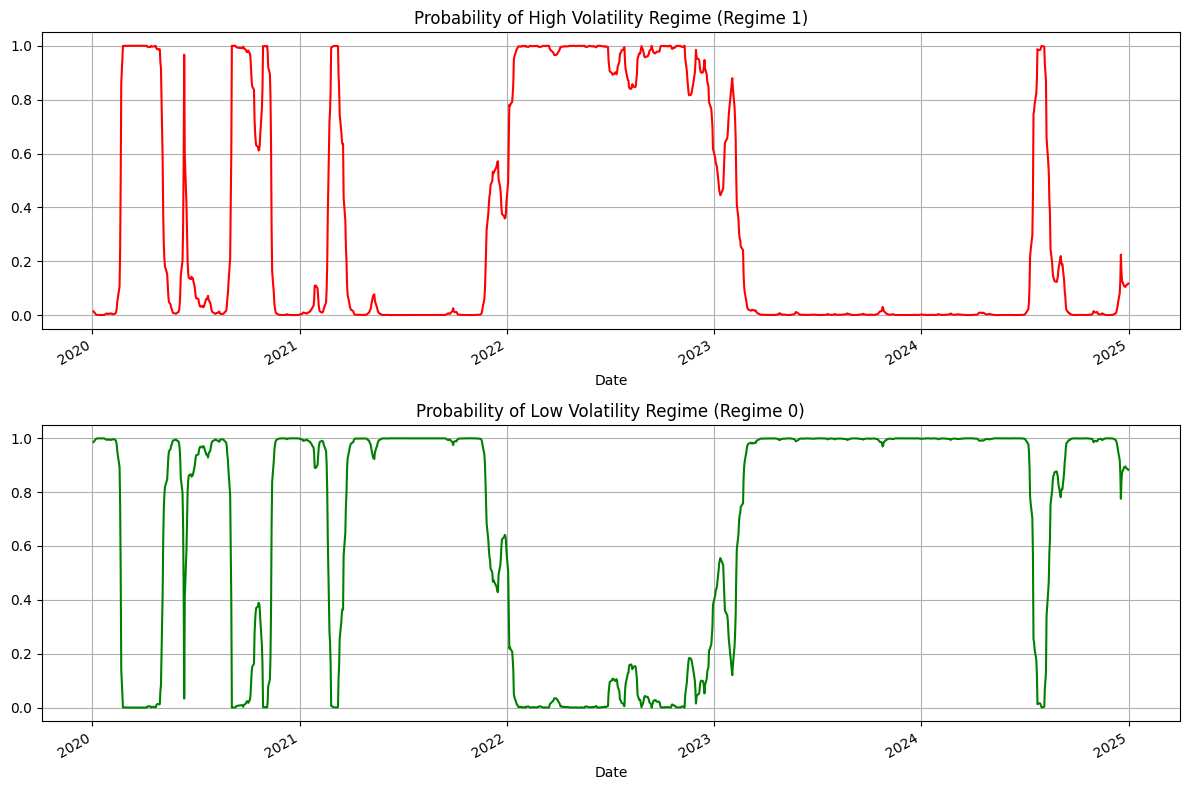

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Plot smoothed probability of Regime 1 (High Volatility)
model_results.smoothed_marginal_probabilities[1].plot(ax=axes[0], title='Probability of High Volatility Regime (Regime 1)', color='red')
axes[0].grid(True)

# Plot smoothed probability of Regime 0 (Low Volatility)
model_results.smoothed_marginal_probabilities[0].plot(ax=axes[1], title='Probability of Low Volatility Regime (Regime 0)', color='green')
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 6. Damage & Challenges

**Problems revealed:**
- **Lagging Detection:** Markov models are often 'backward-looking'; by the time the probability of a regime shift reaches 100%, the market may have already moved significantly.
- **Overfitting:** During the 2022-2023 period, the model fluctuates rapidly between regimes, which might suggest that a 2-state model is too simple for the complex inflation-driven volatility.

**Challenge Assessment:**
- **Modeling Non-stationarity:** The model successfully handles non-stationarity by allowing the variance to change, but it assumes the transition probabilities are constant, which may not hold true during unprecedented global events (like the 2020 pandemic start).

## 7. Directions

To improve the model fit, we could:
1. **Increase Regimes:** Test a 3-regime model (Bear, Bull, and Sideways/Neutral).
2. **Exogenous Variables:** Include the VIX index or interest rate data as 'switching' variables to help the model anticipate transitions faster.

## 8. Deployment

In a real-world scenario, this model would be deployed to **automate risk management**. For example, when the smoothed probability of Regime 1 exceeds 50%, a portfolio could automatically move from high-beta tech stocks to cash or defensive assets to avoid high-volatility drawdowns.